# Algorithm Comparison — Which Method is Best?

This notebook benchmarks three algorithms on the **NAS-Bench-201 × HW-NAS-Bench** problem:
comparing the proposed **MOEA/D + Discrete PSO + SA** hybrid against **NSGA-II** and **Random Search**.

---

## Comparison Metrics

All metrics are computed in the **minimisation** objective space  
$F = (-\text{Accuracy},\ \text{Latency})$, normalised to $[0, 1]^2$ for fair cross-algorithm comparison.

### Hypervolume (HV) — _higher is better_

$$HV(F, r) = \lambda\!\left(\bigcup_{f \in F} [f_1, r_1] \times [f_2, r_2]\right)$$

where $r = (1.1, 1.1)$ is the reference point and $\lambda$ is the Lebesgue measure.  
HV measures the **volume of objective space dominated** by the found Pareto front.  
A larger HV means the algorithm found a front that is simultaneously closer to the ideal  
and spreads more widely across the accuracy–latency trade-off spectrum.

### Inverted Generational Distance (IGD) — _lower is better_

$$IGD(F, P^*) = \frac{1}{|P^*|} \sum_{p \in P^*} \min_{f \in F} \|p - f\|_2$$

where $P^*$ is the **proxy reference front** (non-dominated union of all algorithm runs).  
IGD measures how closely the approximation set **covers** the reference front.  
A lower IGD means the algorithm's front is denser and closer to the best-known solutions.

### Proxy Reference Front $P^*$

Since the true Pareto front of NAS-Bench-201 × HW-NAS-Bench is not analytically known,  
$P^*$ is constructed as the **non-dominated union of all evaluated architectures across all algorithms and seeds**.  
This is the standard unbiased approach used in multi-objective benchmarking literature.

### Additional Indicators

| Indicator | Description |
|---|---|
| **Pareto size** | Number of non-dominated solutions in the aggregate front |
| **Best Accuracy (%)** | Highest accuracy found on the Pareto front |
| **Min Latency (ms)** | Lowest latency found on the Pareto front |
| **Overall Rank** | Sum of HV rank + IGD rank (lower = better overall algorithm) |

---

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, proxy_pareto
)
from pymoo.util.nds.non_dominated_sorting import find_non_dominated

RESULTS_DIR = PROJECT_ROOT / "results"
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def load_archives(glob_pattern: str) -> list[list[dict]]:
    archives = []
    for p in sorted(RESULTS_DIR.glob(glob_pattern)):
        payload = json.loads(p.read_text())
        archives.append(payload["archive"])
    return archives


def load_runs(glob_pattern: str) -> list[dict]:
    """Load full result payloads (archive + metadata) for trajectory plots."""
    runs = []
    for p in sorted(RESULTS_DIR.glob(glob_pattern)):
        runs.append(json.loads(p.read_text()))
    return runs


# Proposed results use seed-suffixed filenames (proposed_res_seed{N}.json).
# Fall back to legacy single-run file if multi-seed results are not yet present.
proposed_archives = load_archives("proposed/proposed_res_seed*.json")
if not proposed_archives:
    proposed_archives = load_archives("proposed/proposed_res_*.json")
    print("WARNING: Using legacy proposed results (single seed). "
          "Run 'python scripts/run_search.py' to generate 5-seed results.")

nsga2_archives    = load_archives("baselines/nsga2_seed*.json")
random_archives   = load_archives("baselines/random_search_seed*.json")

proposed_runs = load_runs("proposed/proposed_res_seed*.json") or load_runs("proposed/proposed_res_*.json")
nsga2_runs    = load_runs("baselines/nsga2_seed*.json")
random_runs   = load_runs("baselines/random_search_seed*.json")

print(f"Proposed runs : {len(proposed_archives)}")
print(f"NSGA-II runs  : {len(nsga2_archives)}")
print(f"Random Search : {len(random_archives)}")

# ── Shared normalisation (based on proxy P*) ─────────────────────────────
all_archives = proposed_archives + nsga2_archives + random_archives
p_star = proxy_pareto(all_archives)

all_pts_min = p_star.min(axis=0)
all_pts_max = p_star.max(axis=0)
range_ = np.where(all_pts_max - all_pts_min > 0, all_pts_max - all_pts_min, 1.0)

def normalise(pts: np.ndarray) -> np.ndarray:
    return (pts - all_pts_min) / range_

REF = np.array([1.1, 1.1])

ALGO_CONFIGS = [
    (proposed_archives, "Proposed (MOEA/D+PSO)", "#1f77b4"),
    (nsga2_archives,    "NSGA-II",               "#ff7f0e"),
    (random_archives,   "Random Search",          "#2ca02c"),
]

Proposed runs : 30
NSGA-II runs  : 30
Random Search : 30


## 1. Summary Comparison Table

Per-seed HV and IGD are computed independently for each run, then averaged.  
The **Overall Rank** is the sum of each algorithm's HV rank and IGD rank — rank 1 is the best.

In [14]:
# ── Summary Comparison Table (Mann-Whitney U + Bonferroni correction) ────────
# Uses src/analysis/stats.py for rigorous non-parametric testing.
# Effect size r = rank-biserial correlation (positive = algorithm beats NSGA-II).
# Bonferroni correction: k = 2 comparisons (Proposed vs NSGA-II, Random vs NSGA-II).

from src.analysis.stats import wilcoxon_ranksum, bonferroni_correction


def per_seed_metrics(archives):
    """Return per-seed (hvs, igds) arrays for a list of run archives."""
    hvs, igds = [], []
    for run in archives:
        pts        = archive_to_points(run)
        front      = get_pareto_front(pts)
        norm_front = normalise(front)
        hvs.append(calc_hv(norm_front, ref_point=REF))
        igds.append(calc_igd(norm_front, normalise(p_star)))
    return np.array(hvs), np.array(igds)


# ── Per-seed metric arrays (reused by the statistical tests cell below) ───────
algo_hvs  = {}
algo_igds = {}
for archives, label, _ in ALGO_CONFIGS:
    if archives:
        algo_hvs[label], algo_igds[label] = per_seed_metrics(archives)

NSGA2_LABEL = "NSGA-II"
nsga2_hv    = algo_hvs.get(NSGA2_LABEL, np.array([]))

# ── Mann-Whitney U: each non-NSGA-II algorithm vs. NSGA-II ───────────────────
non_nsga2_labels = [
    lbl for _, lbl, _ in ALGO_CONFIGS
    if lbl in algo_hvs and lbl != NSGA2_LABEL
]
raw_results = {}
if len(nsga2_hv) > 0:
    for lbl in non_nsga2_labels:
        raw_results[lbl] = wilcoxon_ranksum(algo_hvs[lbl], nsga2_hv)

# Bonferroni correction over k pairwise comparisons vs. NSGA-II
if raw_results:
    p_raw_list  = [raw_results[lbl]["p_value"] for lbl in non_nsga2_labels]
    p_corrected = bonferroni_correction(p_raw_list)
    p_bonf_map  = dict(zip(non_nsga2_labels, p_corrected))
else:
    p_bonf_map = {}

# ── Build results DataFrame with exact required columns ──────────────────────
table_rows = []
for archives, label, _ in ALGO_CONFIGS:
    if not archives:
        continue
    hvs, igds = algo_hvs[label], algo_igds[label]

    if label == NSGA2_LABEL or label not in raw_results:
        p_str, r_str = "—", "—"
    else:
        p_bonf = p_bonf_map[label]
        r      = raw_results[label]["effect_r"]
        sig    = ("***" if p_bonf < 0.001 else "**" if p_bonf < 0.01
                  else "*" if p_bonf < 0.05 else "n.s.")
        p_str  = f"{p_bonf:.4f} ({sig})"
        r_str  = f"{r:+.4f}"

    table_rows.append({
        "Algorithm":             label,
        "HV (mean ± std)":       f"{hvs.mean():.4f} ± {hvs.std():.4f}",
        "IGD (mean ± std)":      f"{igds.mean():.4f} ± {igds.std():.4f}",
        "vs. NSGA-II (p-value)": p_str,
        "Effect size r":         r_str,
    })

df = pd.DataFrame(table_rows).set_index("Algorithm")

SEP = "=" * 92
print(SEP)
print("  ALGORITHM COMPARISON TABLE")
print(f"  Mann-Whitney U (two-sided) | Bonferroni-corrected p-values"
      f" (k={len(non_nsga2_labels)} comparisons)")
print("  Effect size r = rank-biserial correlation"
      "  (positive = algorithm better than NSGA-II on HV)")
print(SEP)
print(df.to_string())
print()
print("  *** p<0.001  ** p<0.01  * p<0.05  n.s. = not significant after correction")
print("  |r| interpretation: >0.5 large | 0.3–0.5 medium | <0.3 small  (Cohen 1992)")
print(SEP)


  ALGORITHM COMPARISON TABLE
  Mann-Whitney U (two-sided) | Bonferroni-corrected p-values (k=2 comparisons)
  Effect size r = rank-biserial correlation  (positive = algorithm better than NSGA-II on HV)
                       HV (mean ± std) IGD (mean ± std) vs. NSGA-II (p-value) Effect size r
Algorithm                                                                                  
Proposed (MOEA/D+PSO)  1.0471 ± 0.0008  0.0081 ± 0.0051          0.0006 (***)       +0.5422
NSGA-II                1.0475 ± 0.0028  0.0071 ± 0.0049                     —             —
Random Search          1.0462 ± 0.0010  0.0127 ± 0.0058          0.0000 (***)       +0.6444

  *** p<0.001  ** p<0.01  * p<0.05  n.s. = not significant after correction
  |r| interpretation: >0.5 large | 0.3–0.5 medium | <0.3 small  (Cohen 1992)


## 2. HV and IGD Bar Charts

Each bar shows the **mean ± std** across seeds.  
Individual seed values are overlaid as scatter points for full transparency.

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/comparison_bars.pdf


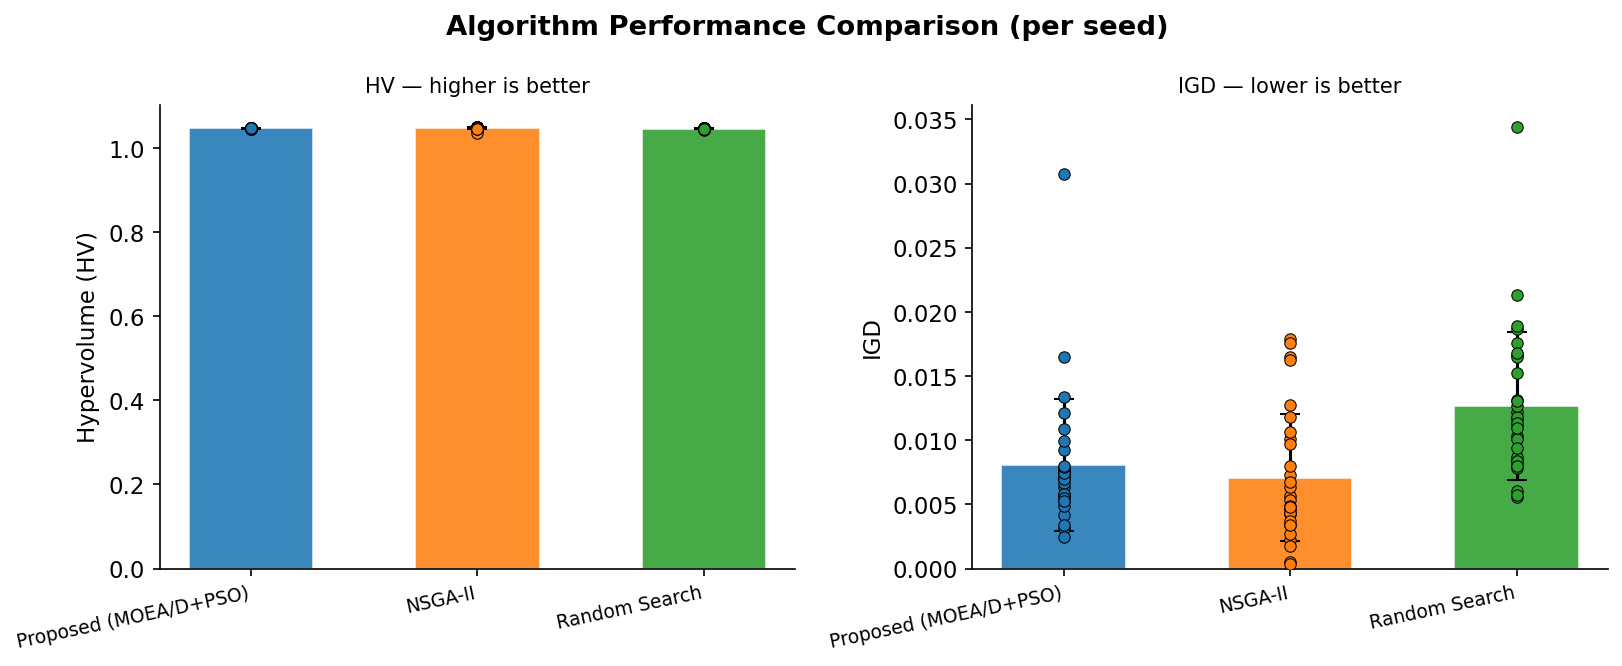

In [15]:
bar_data = []
colors_map = {label: color for _, label, color in ALGO_CONFIGS}

for archives, label, _ in ALGO_CONFIGS:
    if not archives:
        continue
    hvs_run, igds_run = [], []
    for run in archives:
        pts        = archive_to_points(run)
        front      = get_pareto_front(pts)
        norm_front = normalise(front)
        hvs_run.append(calc_hv(norm_front, ref_point=REF))
        igds_run.append(calc_igd(norm_front, normalise(p_star)))
    bar_data.append((label, hvs_run, igds_run))

fig2, (ax_hv, ax_igd) = plt.subplots(1, 2, figsize=(11, 4.5))
fig2.suptitle("Algorithm Performance Comparison (per seed)", fontweight="bold")

labels_plot = [d[0] for d in bar_data]
x           = np.arange(len(labels_plot))
width       = 0.55
colors_bar  = [colors_map[l] for l in labels_plot]

hv_means = [np.mean(d[1]) for d in bar_data]
hv_stds  = [np.std(d[1])  for d in bar_data]
ax_hv.bar(x, hv_means, yerr=hv_stds, capsize=5, color=colors_bar,
            width=width, edgecolor="white", linewidth=0.8, alpha=0.88)
ax_hv.set_xticks(x)
ax_hv.set_xticklabels(labels_plot, rotation=12, ha="right", fontsize=9)
ax_hv.set_ylabel("Hypervolume (HV)")
ax_hv.set_title("HV — higher is better", fontsize=10)
for i, d in enumerate(bar_data):
    for v in d[1]:
        ax_hv.scatter(i, v, color=colors_bar[i], edgecolors="black",
                        s=30, zorder=5, linewidths=0.5)

igd_means = [np.mean(d[2]) for d in bar_data]
igd_stds  = [np.std(d[2])  for d in bar_data]
ax_igd.bar(x, igd_means, yerr=igd_stds, capsize=5, color=colors_bar,
            width=width, edgecolor="white", linewidth=0.8, alpha=0.88)
ax_igd.set_xticks(x)
ax_igd.set_xticklabels(labels_plot, rotation=12, ha="right", fontsize=9)
ax_igd.set_ylabel("IGD")
ax_igd.set_title("IGD — lower is better", fontsize=10)
for i, d in enumerate(bar_data):
    for v in d[2]:
        ax_igd.scatter(i, v, color=colors_bar[i], edgecolors="black",
                        s=30, zorder=5, linewidths=0.5)

fig2.tight_layout()
out2 = PROJECT_ROOT / "results" / "comparison_bars.pdf"
fig2.savefig(out2, bbox_inches="tight")
print(f"Saved → {out2}")
plt.show()

## 3. Baseline Pareto Overlay

This plot overlays the aggregate Pareto fronts from all seeds, showing the geometric trade-off sets of Proposed MOEA/D+PSO, NSGA-II, and Random Search.

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/comparison_pareto_overlay.pdf


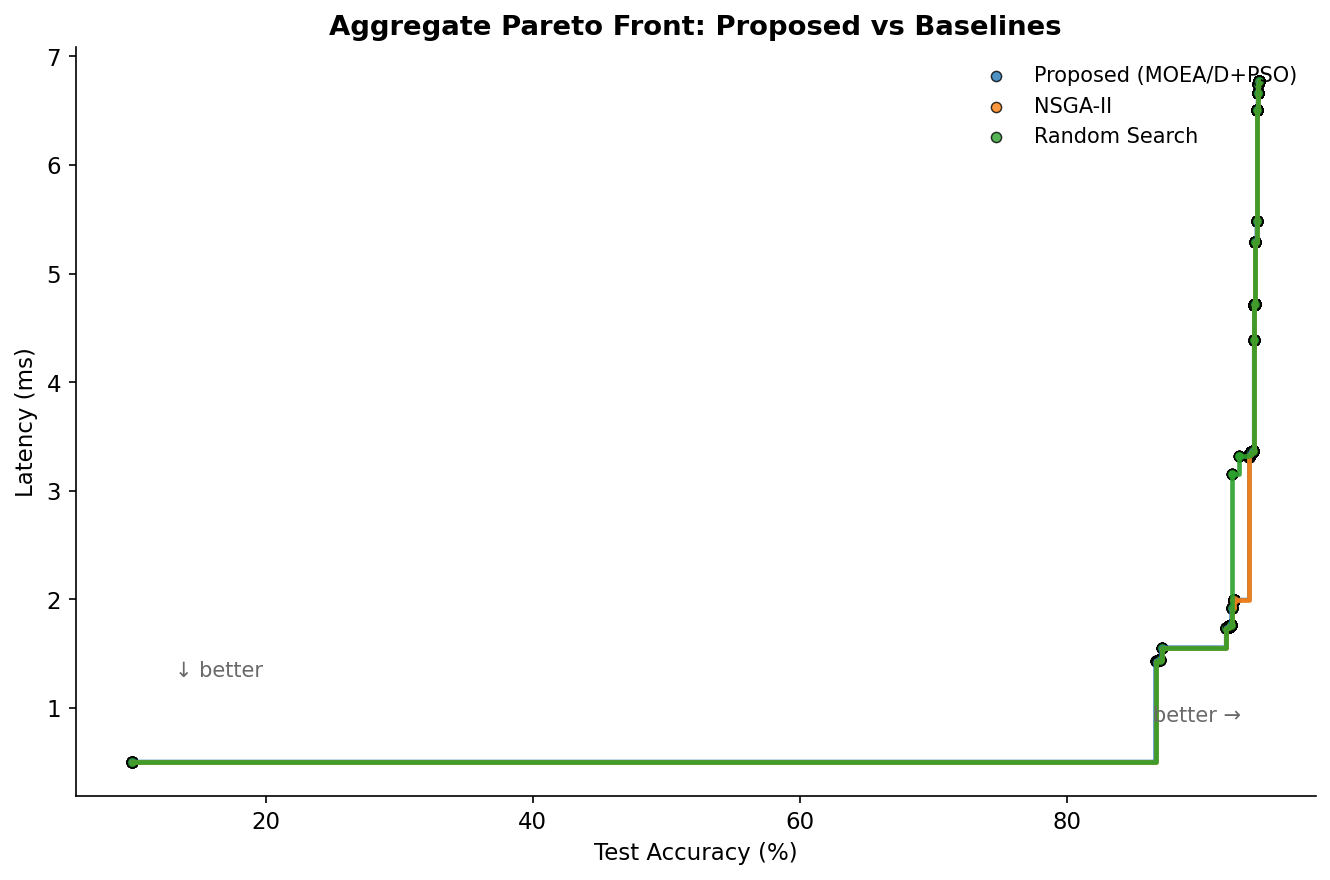

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
for archives, label, color in ALGO_CONFIGS:
    if not archives:
        continue
    all_pts = np.vstack([archive_to_points(run) for run in archives])
    front = get_pareto_front(all_pts)
    acc = -front[:, 0]
    lat = front[:, 1]
    order = np.argsort(acc)
    ax.step(acc[order], lat[order], where="post", color=color, linewidth=2.25, alpha=0.9)
    ax.scatter(acc[order], lat[order], s=24, color=color, edgecolors="black", linewidth=0.7, alpha=0.8, label=label)

ax.set_xlabel("Test Accuracy (%)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Aggregate Pareto Front: Proposed vs Baselines", fontweight="bold")
ax.legend(frameon=False, fontsize=10, loc="upper right")
ax.annotate("better →", xy=(0.94, 0.10), xycoords="axes fraction", ha="right", fontsize=10, color="dimgray")
ax.annotate("↓ better", xy=(0.08, 0.16), xycoords="axes fraction", ha="left", fontsize=10, color="dimgray")
ax.grid(False)

fig.tight_layout()
out_path = PROJECT_ROOT / "results" / "comparison_pareto_overlay.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

In [17]:
# ── Detailed Statistical Tests: Wilcoxon Rank-Sum (all metrics) ──────────────
# Extends the summary table: tests both HV and IGD independently.
# Reuses algo_hvs / algo_igds computed in the previous cell.
# Bonferroni correction: 2 baselines × 2 metrics = 4 tests → α* = 0.05/4 = 0.0125

from src.analysis.stats import wilcoxon_ranksum, bonferroni_correction

prop_hv  = algo_hvs.get("Proposed (MOEA/D+PSO)", np.array([]))
prop_igd = algo_igds.get("Proposed (MOEA/D+PSO)", np.array([]))
nsga2_hv_det  = algo_hvs.get("NSGA-II", np.array([]))
nsga2_igd_det = algo_igds.get("NSGA-II", np.array([]))
rand_hv  = algo_hvs.get("Random Search", np.array([]))
rand_igd = algo_igds.get("Random Search", np.array([]))

ALPHA      = 0.05
N_TESTS    = 4       # 2 baselines × 2 metrics
ALPHA_CORR = ALPHA / N_TESTS  # 0.0125

raw_p_values = []
comparisons_meta = [
    ("vs NSGA-II", "HV",  prop_hv,  nsga2_hv_det,  False),
    ("vs NSGA-II", "IGD", prop_igd, nsga2_igd_det,  True),
    ("vs Random",  "HV",  prop_hv,  rand_hv,        False),
    ("vs Random",  "IGD", prop_igd, rand_igd,        True),
]
for _, _, a, b, _ in comparisons_meta:
    if len(a) > 0 and len(b) > 0:
        raw_p_values.append(wilcoxon_ranksum(a, b)["p_value"])
    else:
        raw_p_values.append(float("nan"))

p_bonf_all = bonferroni_correction([p for p in raw_p_values if not np.isnan(p)])
p_bonf_iter = iter(p_bonf_all)

rows = []
for comp_label, metric, a, b, lower_better in comparisons_meta:
    if len(a) == 0 or len(b) == 0:
        continue
    result = wilcoxon_ranksum(a, b)
    p_bonf = next(p_bonf_iter)
    delta  = float(np.mean(a) - np.mean(b))
    direction = "Proposed better" if (delta > 0) != lower_better else "Proposed worse"
    sig_marker = ("***" if p_bonf < 0.001 else "**"  if p_bonf < 0.01
                  else "*"   if p_bonf < ALPHA_CORR  else "n.s.")
    rows.append({
        "Comparison": comp_label,
        "Metric":     metric,
        "U-stat":     f"{result['U_stat']:.1f}",
        "p (raw)":    f"{result['p_value']:.4f}",
        "p (Bonf.)":  f"{p_bonf:.4f}",
        "sig.":       sig_marker,
        "Effect r":   f"{result['effect_r']:+.4f}",
        "Δ mean":     f"{delta:+.4f}",
        "Direction":  direction,
    })

df_stats = pd.DataFrame(rows).set_index(["Comparison", "Metric"])
SEP2 = "─" * 95
print("Wilcoxon Rank-Sum Test  —  Proposed vs. Baselines  (detailed, both metrics)")
print(f"H₀: identical distributions (two-sided)  |  α={ALPHA}  |  Bonferroni α*={ALPHA_CORR:.4f}")
print(SEP2)
print(df_stats.to_string())
print(SEP2)
print("*** p<0.001  ** p<0.01  * p<α*  n.s. not significant after Bonferroni correction")
print("Effect r = rank-biserial correlation | Δ mean: Proposed − Baseline")


Wilcoxon Rank-Sum Test  —  Proposed vs. Baselines  (detailed, both metrics)
H₀: identical distributions (two-sided)  |  α=0.05  |  Bonferroni α*=0.0125
───────────────────────────────────────────────────────────────────────────────────────────────
                  U-stat p (raw) p (Bonf.)  sig. Effect r   Δ mean        Direction
Comparison Metric                                                                  
vs NSGA-II HV      206.0  0.0003    0.0013    **  +0.5422  -0.0004   Proposed worse
           IGD     542.0  0.1761    0.7045  n.s.  -0.2044  +0.0010   Proposed worse
vs Random  HV      694.0  0.0003    0.0013    **  -0.5422  +0.0010  Proposed better
           IGD     167.0  0.0000    0.0001   ***  +0.6289  -0.0046  Proposed better
───────────────────────────────────────────────────────────────────────────────────────────────
*** p<0.001  ** p<0.01  * p<α*  n.s. not significant after Bonferroni correction
Effect r = rank-biserial correlation | Δ mean: Proposed − Baseline


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/convergence_trajectory.pdf


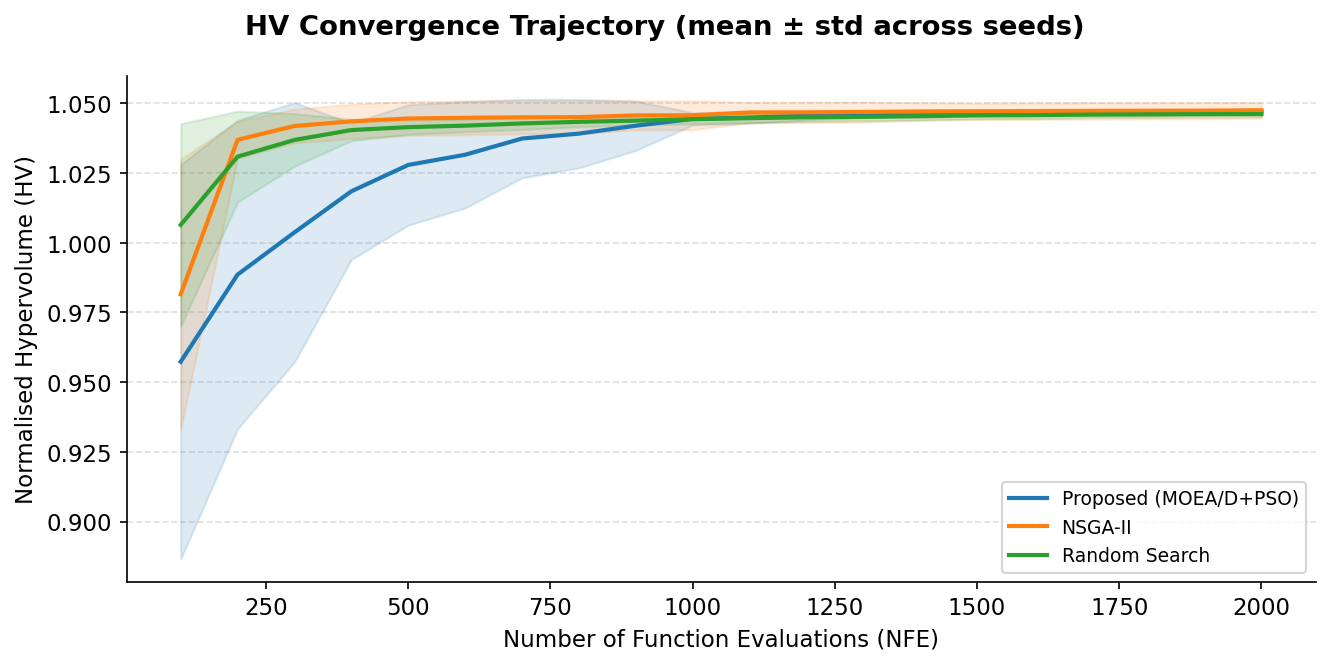

In [18]:
# ── HV Convergence Trajectory: HV vs NFE ─────────────────────────────────────
# For each run, we reconstruct the Pareto front at every NFE checkpoint by
# slicing archive[:nfe] — valid because archive entries are in evaluation order.
# This requires results generated by the updated scripts (which save nfe_checkpoints).

def compute_trajectory(runs: list[dict]) -> list[np.ndarray]:
    """
    For each run, return an array of shape (n_checkpoints, 2) = [(nfe, hv), ...].
    Runs without nfe_checkpoints in their metadata are skipped.
    """
    trajectories = []
    for run in runs:
        checkpoints = run.get("metadata", {}).get("nfe_checkpoints", [])
        if not checkpoints:
            continue
        archive = run["archive"]
        pts_seq = []
        for nfe in checkpoints:
            slice_ = archive[:nfe]
            if not slice_:
                continue
            pts        = archive_to_points(slice_)
            front      = get_pareto_front(pts)
            norm_front = normalise(front)
            hv         = calc_hv(norm_front, ref_point=REF)
            pts_seq.append((nfe, hv))
        if pts_seq:
            trajectories.append(np.array(pts_seq))
    return trajectories

traj_proposed = compute_trajectory(proposed_runs)
traj_nsga2    = compute_trajectory(nsga2_runs)
traj_random   = compute_trajectory(random_runs)

if not any([traj_proposed, traj_nsga2, traj_random]):
    print("No nfe_checkpoints found in result files.")
    print("Re-run 'python scripts/run_search.py' and 'python scripts/run_baselines.py'")
    print("to generate results with convergence trajectory data.")
else:
    TRAJ_CONFIGS = [
        (traj_proposed, "Proposed (MOEA/D+PSO)", "#1f77b4"),
        (traj_nsga2,    "NSGA-II",               "#ff7f0e"),
        (traj_random,   "Random Search",          "#2ca02c"),
    ]

    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.suptitle("HV Convergence Trajectory (mean ± std across seeds)", fontweight="bold")

    for trajs, label, color in TRAJ_CONFIGS:
        if not trajs:
            continue
        # Align all seeds to the same NFE axis (use the shortest trajectory)
        nfe_axis = trajs[0][:, 0]
        for t in trajs[1:]:
            n = min(len(nfe_axis), len(t))
            nfe_axis = nfe_axis[:n]
        hv_matrix = np.array([t[:len(nfe_axis), 1] for t in trajs])  # (seeds, T)

        mean_hv = hv_matrix.mean(axis=0)
        std_hv  = hv_matrix.std(axis=0)

        ax.plot(nfe_axis, mean_hv, label=label, color=color, linewidth=2)
        ax.fill_between(nfe_axis, mean_hv - std_hv, mean_hv + std_hv,
                        color=color, alpha=0.15)

    ax.set_xlabel("Number of Function Evaluations (NFE)")
    ax.set_ylabel("Normalised Hypervolume (HV)")
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    fig.tight_layout()

    out = PROJECT_ROOT / "results" / "convergence_trajectory.pdf"
    fig.savefig(out, bbox_inches="tight")
    print(f"Saved → {out}")
    plt.show()

## 3. Top-5 Pareto-Optimal Architectures per Algorithm

From the aggregate non-dominated front of each algorithm, the top 5 architectures  
are listed in descending order of accuracy.  
Each row shows the full 6-edge operation sequence of the NAS-Bench-201 cell.

In [20]:
OPS = ["none", "skip_connect", "avg_pool_3x3", "nor_conv_1x1", "nor_conv_3x3"]

def best_archs_table(archives, label, n=5):
    if not archives:
        return
    all_pts  = np.vstack([archive_to_points(a) for a in archives])
    all_raw  = [e for run in archives for e in run]
    front_idx = find_non_dominated(all_pts)

    front_pts = all_pts[front_idx]
    front_raw = [all_raw[i] for i in front_idx]

    order  = np.argsort(front_pts[:, 0])   # ascending -acc = descending accuracy
    rows_t = []
    for rank, i in enumerate(order[:n], 1):
        e = front_raw[i]
        ops_str = " | ".join(OPS[o] for o in e["arch"])
        rows_t.append({
            "Rank":         rank,
            "Accuracy (%)": f"{e['accuracy']:.2f}",
            "Latency (ms)": f"{e['latency']:.4f}",
            "Architecture": ops_str,
        })
    print(f"\n  TOP-{n} PARETO ARCHITECTURES — {label}")
    print(pd.DataFrame(rows_t).set_index("Rank").to_string())

for archives, label, _ in ALGO_CONFIGS:
    for archives, label, _ in ALGO_CONFIGS:
        if not archives:
            continue

        reduced_archives = []
        for run in archives:
            run_pts = archive_to_points(run)
            if run_pts.size == 0:
                continue
            nd_idx = np.atleast_1d(find_non_dominated(run_pts))
            reduced_archives.append([run[i] for i in nd_idx])

        if reduced_archives:
            best_archs_table(reduced_archives, label)


  TOP-5 PARETO ARCHITECTURES — Proposed (MOEA/D+PSO)
     Accuracy (%) Latency (ms)                                                                             Architecture
Rank                                                                                                                   
1           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3
2           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3
3           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3
4           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3
5           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3

  TOP-5 PARETO ARCHITECTURES — NSGA-II
     Accuracy (%) Latency (ms)                                    